In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving shopping_trends_updated.csv to shopping_trends_updated.csv


In [ ]:
df = pd.read_csv("shopping_trends_updated.csv")

df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [ ]:
print("Rows and Columns:", df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nData Information:")
df.info()

Rows and Columns: (3900, 18)

Column Names:
Index(['Customer ID', 'Age', 'Gender', 'Item Purchased', 'Category',
       'Purchase Amount (USD)', 'Location', 'Size', 'Color', 'Season',
       'Review Rating', 'Subscription Status', 'Shipping Type',
       'Discount Applied', 'Promo Code Used', 'Previous Purchases',
       'Payment Method', 'Frequency of Purchases'],
      dtype='object')

Missing Values:
Customer ID               0
Age                       0
Gender                    0
Item Purchased            0
Category                  0
Purchase Amount (USD)     0
Location                  0
Size                      0
Color                     0
Season                    0
Review Rating             0
Subscription Status       0
Shipping Type             0
Discount Applied          0
Promo Code Used           0
Previous Purchases        0
Payment Method            0
Frequency of Purchases    0
dtype: int64

Data Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 en

In [ ]:
df.head(10)

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually
5,6,46,Male,Sneakers,Footwear,20,Wyoming,M,White,Summer,2.9,Yes,Standard,Yes,Yes,14,Venmo,Weekly
6,7,63,Male,Shirt,Clothing,85,Montana,M,Gray,Fall,3.2,Yes,Free Shipping,Yes,Yes,49,Cash,Quarterly
7,8,27,Male,Shorts,Clothing,34,Louisiana,L,Charcoal,Winter,3.2,Yes,Free Shipping,Yes,Yes,19,Credit Card,Weekly
8,9,26,Male,Coat,Outerwear,97,West Virginia,L,Silver,Summer,2.6,Yes,Express,Yes,Yes,8,Venmo,Annually
9,10,57,Male,Handbag,Accessories,31,Missouri,M,Pink,Spring,4.8,Yes,2-Day Shipping,Yes,Yes,4,Cash,Quarterly


In [ ]:
df.describe()

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3900.000000,3900.000000
mean,1950.500000,44.068462,59.764359,3.749949,25.351538
std,1125.977353,15.207589,23.685392,0.716223,14.447125
min,1.000000,18.000000,20.000000,2.500000,1.000000
25%,975.750000,31.000000,39.000000,3.100000,13.000000
50%,1950.500000,44.000000,60.000000,3.700000,25.000000
75%,2925.250000,57.000000,81.000000,4.400000,38.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000


In [ ]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [ ]:
print("Gender:", df["Gender"].unique())
print("Category:", df["Category"].unique())
print("Season:", df["Season"].unique())
print("Payment Methods:", df["Payment Method"].unique())
print("Frequency:", df["Frequency of Purchases"].unique())

Gender: ['Male' 'Female']
Category: ['Clothing' 'Footwear' 'Outerwear' 'Accessories']
Season: ['Winter' 'Spring' 'Summer' 'Fall']
Payment Methods: ['Venmo' 'Cash' 'Credit Card' 'PayPal' 'Bank Transfer' 'Debit Card']
Frequency: ['Fortnightly' 'Weekly' 'Annually' 'Quarterly' 'Bi-Weekly' 'Monthly'
 'Every 3 Months']


In [ ]:
print("Unique Customer IDs:", df["Customer ID"].nunique())

Unique Customer IDs: 3900


In [ ]:
print("Total Purchase Amount:", df["Purchase Amount (USD)"].sum())
print("Average Purchase Amount:", df["Purchase Amount (USD)"].mean())
print("Minimum Purchase Amount:", df["Purchase Amount (USD)"].min())
print("Maximum Purchase Amount:", df["Purchase Amount (USD)"].max())

Total Purchase Amount: 233081
Average Purchase Amount: 59.76435897435898
Minimum Purchase Amount: 20
Maximum Purchase Amount: 100


Find the most popular categories


In [ ]:
category_counts = df["Category"].value_counts()

print(category_counts)

Category
Clothing       1737
Accessories    1240
Footwear        599
Outerwear       324
Name: count, dtype: int64


In [ ]:
category_sales = df.groupby("Category")["Purchase Amount (USD)"].sum().sort_values(ascending=False)

print(category_sales)

Category
Clothing       104264
Accessories     74200
Footwear        36093
Outerwear       18524
Name: Purchase Amount (USD), dtype: int64


Create first chart

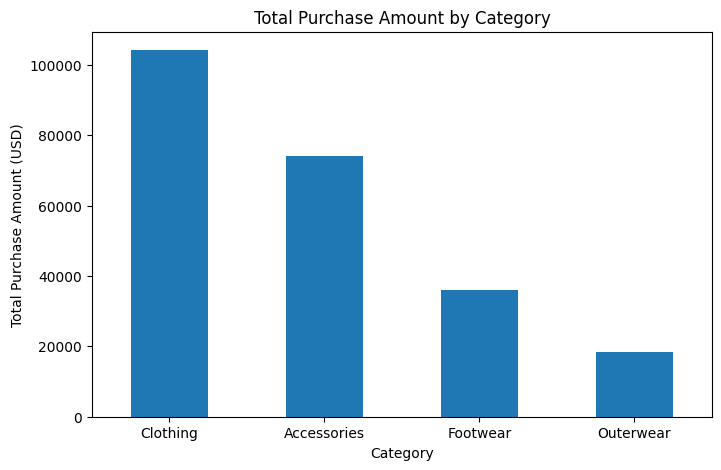

In [ ]:
category_sales = (
    df.groupby("Category")["Purchase Amount (USD)"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))

category_sales.plot(kind="bar")

plt.title("Total Purchase Amount by Category")
plt.xlabel("Category")
plt.ylabel("Total Purchase Amount (USD)")
plt.xticks(rotation=0)

plt.show()

create the purchase-count chart

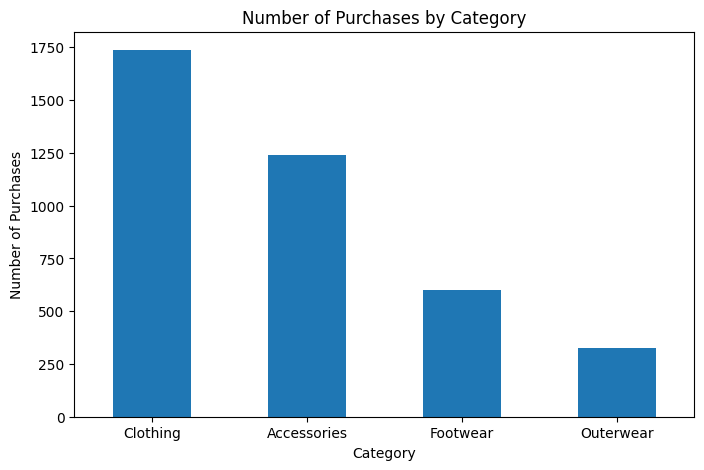

In [ ]:
Category_counts = df["Category"].value_counts()
plt.figure(figsize=(8, 5))

category_counts.plot(kind="bar")
plt.title("Number of Purchases by Category")
plt.xlabel("Category")
plt.ylabel("Number of Purchases")
plt.xticks(rotation=0)

plt.show()

Gender-wise Analysis


In [ ]:
gender_count = df["Gender"].value_counts()

print(gender_count)

Gender
Male      2652
Female    1248
Name: count, dtype: int64


In [ ]:
gender_sales = (
    df.groupby("Gender")["Purchase Amount (USD)"]
      .sum()
      .sort_values(ascending=False)
)

print(gender_sales)

Gender
Male      157890
Female     75191
Name: Purchase Amount (USD), dtype: int64


In [ ]:
top_items = (
    df.groupby("Item Purchased")["Purchase Amount (USD)"]
      .sum()
      .sort_values(ascending=False)
)

print(top_items.head(10))

Item Purchased
Blouse        10410
Shirt         10332
Dress         10320
Pants         10090
Jewelry       10010
Sunglasses     9649
Belt           9635
Scarf          9561
Sweater        9462
Shorts         9433
Name: Purchase Amount (USD), dtype: int64


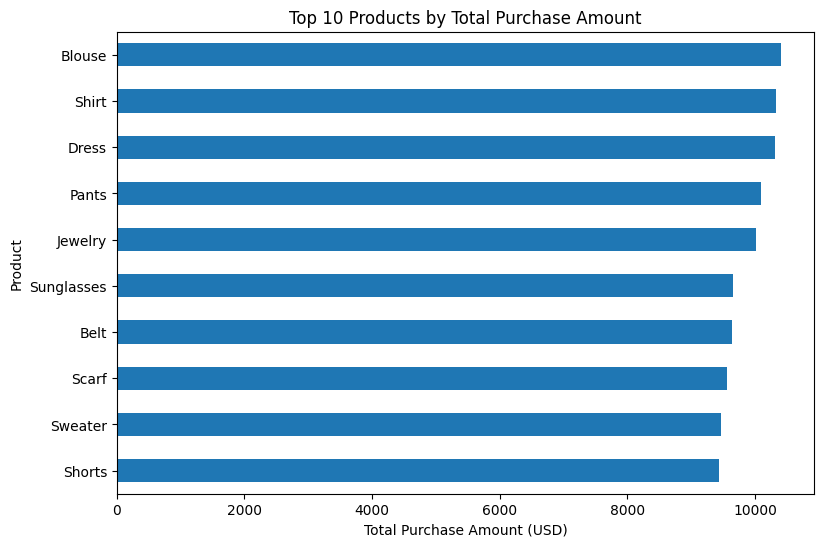

In [ ]:
top_10_items = top_items.head(10).sort_values()

plt.figure(figsize=(9, 6))

top_10_items.plot(kind="barh")

plt.title("Top 10 Products by Total Purchase Amount")
plt.xlabel("Total Purchase Amount (USD)")
plt.ylabel("Product")

plt.show()

Subscription Analysis


In [ ]:
subscription_count = df["Subscription Status"].value_counts()

print(subscription_count)

Subscription Status
No     2847
Yes    1053
Name: count, dtype: int64


Total Purchase Amount &Average Purchase amount

In [ ]:
subscription_sales = (
    df.groupby("Subscription Status")["Purchase Amount (USD)"]
      .sum()
)

print(subscription_sales)
subscription_avg = (
    df.groupby("Subscription Status")["Purchase Amount (USD)"]
      .mean()
)

print(subscription_avg)

Subscription Status
No     170436
Yes     62645
Name: Purchase Amount (USD), dtype: int64
Subscription Status
No     59.865121
Yes    59.491928
Name: Purchase Amount (USD), dtype: float64


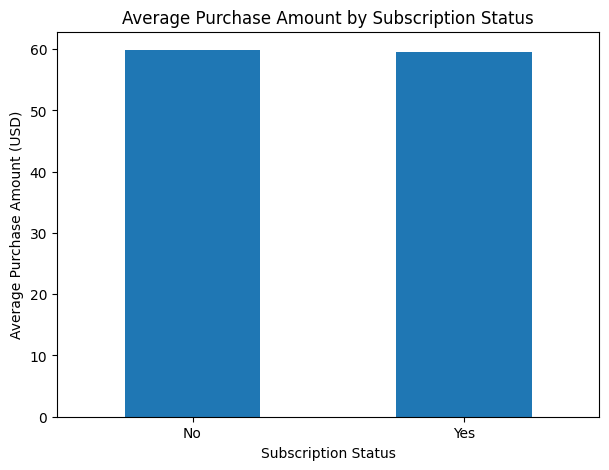

In [ ]:
plt.figure(figsize=(7, 5))

subscription_avg.plot(kind="bar")

plt.title("Average Purchase Amount by Subscription Status")
plt.xlabel("Subscription Status")
plt.ylabel("Average Purchase Amount (USD)")
plt.xticks(rotation=0)

plt.show()

In [ ]:
import sqlite3

conn = sqlite3.connect("shopping.db")

df.to_sql("shopping", conn, if_exists="replace", index=False)

result = pd.read_sql_query("""
SELECT
    Category,
    COUNT(*) AS purchase_count,
    SUM("Purchase Amount (USD)") AS total_sales
FROM shopping
GROUP BY Category
ORDER BY total_sales DESC;
""", conn)

result

,Category,purchase_count,total_sales
0,Clothing,1737,104264
1,Accessories,1240,74200
2,Footwear,599,36093
3,Outerwear,324,18524
